## **AI and Machine Learning Part A (Classification)**

<b>Name:</b> Khambhati Moiz Huzefa

<b>Class:</b> DAAA/FT/1B/01

<b>Admin No:</b> P2508625

<br>

### **Background Information**

This assignment uses the **factory_data.csv** dataset, which was collected from a manufacturing factory’s production environment. The dataset contains various operational and sensor measurements recorded from different machines. From a quality control perspective, the objective is to build a **machine learning model** that can predict whether a machine is **operating normally** or **faulty** based on its recorded attributes. This classification task supports **predictive maintenance**, helping to detect potential failures early and improve factory efficiency.


<br>

### **Objectives for This Assignment**

The primary objective of this assignment is to apply the complete **machine learning workflow** to a real-world **classification problem** involving factory machine status prediction. Through this project, I aim to:

* Understand how to use **pandas** and **NumPy** for data loading, preprocessing, and feature manipulation.
* Conduct **Exploratory Data Analysis (EDA)** to identify patterns, trends, and missing values in the dataset.
* Apply appropriate **data cleaning** and **feature engineering** techniques to enhance model performance.
* Build and compare **classification models** using **scikit-learn**, such as *Random Forest* and *K-Nearest Neighbors (KNN)*.
* Evaluate model performance using key metrics, including **accuracy**, **precision**, **recall**, and **F1-score**.
* Visualize results effectively using **Matplotlib** and **Seaborn** to support data-driven interpretations.
* Reflect on how **data quality**, **feature selection**, and **preprocessing decisions** influence the model’s accuracy and reliability.

Ultimately, the goal is to develop a robust model capable of accurately predicting whether a factory machine is **working properly** or **faulty**, while gaining a practical understanding of the end-to-end **machine learning pipeline**.


<br>

### **Importing the libraries required**

In [56]:
#Data Processing

import pandas as pd 
import numpy as np

#Training the Model


#Data Visualisation
import seaborn as sns 
import matplotlib.pyplot as plt


<br>

### **Data Understanding**

The dataset used in this study, *factory_data.csv*, contains operational and sensor readings collected from industrial machinery. Each record corresponds to a single machine instance, describing its performance conditions and current operating status. The data consists of 20,000 observations and nine features, combining both numerical and categorical variables such as temperature, torque, rotation speed, and product identifiers.

The primary goal of this analysis is to develop a **predictive model** capable of determining whether a machine is functioning normally or experiencing a fault, based on these recorded attributes. This defines a **binary classification problem**, where the input features — including *Ambient Temperature*, *Process Temperature*, *Rotation Speed (rpm)*, *Torque (Nm)*, *Tool Wear (min)*, and *Quality* — collectively influence the prediction of the target variable.

The **output variable**, *Machine Status*, represents the operational condition of the machine and serves as the target label for classification:

* **0** → Machine is operating normally
* **1** → Machine is faulty or non-operational

Understanding the relationships between these features is crucial for identifying which parameters most strongly indicate potential machine failure. This insight not only aids in improving predictive accuracy but also supports **predictive maintenance**, allowing early detection of equipment faults and reducing costly downtime.



<br>

### **Data Overview**

The dataset, **factory_data**, comprises information collected from factory machines operating under various environmental and mechanical conditions. It contains **20,000 records and 9 attributes**, each describing a specific aspect of machine performance or product quality. The variables are summarized below:

| **Feature Name**         | **Description**                                                                                            |
| ------------------------ | ---------------------------------------------------------------------------------------------------------- |
| **Unique ID**            | A unique identifier assigned to each machine record.                                                       |
| **Product ID**           | The product code associated with each manufacturing instance.                                              |
| **Quality**              | Categorical measure of product quality with three levels — **L** (Low), **M** (Medium), and **H** (High).  |
| **Ambient T (°C)**       | The ambient temperature in degrees Celsius surrounding the machine during operation.                       |
| **Process T (°C)**       | The process temperature in degrees Celsius within the machinery during production.                         |
| **Rotation Speed (rpm)** | The machine’s rotation speed measured in **revolutions per minute (rpm)**.                                 |
| **Torque (Nm)**          | The torque produced by the machine, measured in **Newton-meters (Nm)**.                                    |
| **Tool Wear (min)**      | The total tool usage time before replacement, recorded in **minutes**.                                     |
| **Machine Status**       | The target variable indicating machine condition: **0** = normal operation, **1** = faulty/abnormal state. |

Overall, the dataset includes both **categorical** (e.g., *Product ID*, *Quality*, *Machine Status*) and **numerical** (e.g., *Temperature*, *Speed*, *Torque*, *Tool Wear*) attributes, providing a comprehensive view of machine behavior under different conditions. This blend of operational and environmental features makes the dataset suitable for building predictive models aimed at early fault detection and maintenance optimization.

---

Would you like me to combine this with your **Data Understanding** section into a single, polished block (so it reads smoothly as one continuous part of your report)?


<br>

### **Explanatory Data Analysis of factory_data.csv dataset**

In [57]:

#importing the dataset factory_data.csv as df
df = pd.read_csv("datasets/factory_data.csv")

print("Shape:",df.shape)
print("\nIndex:",df.index)
print("\nColumns:",df.columns)
print("\nCount of non-missing values:\n",df.count())
print("\nDataFrame Info:\n")
df.info()
print("\nDescriptive Statistics:\n", df.describe())
print("\nData Types: \n", df.dtypes)

df.head()


Shape: (20000, 9)

Index: RangeIndex(start=0, stop=20000, step=1)

Columns: Index(['Unique ID', 'Product ID', 'Quality', 'Ambient T (C)', 'Process T (C)',
       'Rotation Speed (rpm)', 'Torque (Nm)', 'Tool Wear (min)',
       'Machine Status'],
      dtype='object')

Count of non-missing values:
 Unique ID               20000
Product ID              20000
Quality                 19009
Ambient T (C)           20000
Process T (C)           19600
Rotation Speed (rpm)    18812
Torque (Nm)             20000
Tool Wear (min)         20000
Machine Status          20000
dtype: int64

DataFrame Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unique ID             20000 non-null  int64  
 1   Product ID            20000 non-null  object 
 2   Quality               19009 non-null  object 
 3   Ambient T (C)         20000 non-

,Unique ID,Product ID,Quality,Ambient T (C),Process T (C),Rotation Speed (rpm),Torque (Nm),Tool Wear (min),Machine Status
0,1,K12965,M,24.95,35.45,1551.0,42.8,0,0
1,2,Z62710,L,25.05,35.55,1408.0,46.3,3,0
2,3,T20224,L,24.95,35.35,1498.0,49.4,5,0
3,4,Z33024,L,25.05,35.45,1433.0,39.5,7,0
4,5,Z52839,L,25.05,35.55,1408.0,40.0,9,0


The dataset, `factory_data.csv`, contains **20,000 records and 9 columns**, representing various sensor readings and operational details from factory machinery. The index ranges from 0 to 19,999, indicating that each entry corresponds to an individual machine observation.

#### **Dataset Structure**

The dataset includes both categorical and numerical features:

* **Categorical Columns:** `Product ID`, `Quality`, and `Machine Status`
* **Numerical Columns:** `Unique ID`, `Ambient T (C)`, `Process T (C)`, `Rotation Speed (rpm)`, `Torque (Nm)`, and `Tool Wear (min)`

From the data types summary, four columns are stored as `float64`, three as `int64`, and two as `object` types.

#### **Missing Values**

Most columns are complete, though some contain missing entries:

* `Quality` → 991 missing values
* `Process T (C)` → 400 missing values
* `Rotation Speed (rpm)` → 1,188 missing values

This suggests minor data quality issues that may require cleaning or imputation during preprocessing.

#### **Descriptive Statistics**

The numerical features show a well-defined range of operational values:

* **Ambient Temperature (C):** Ranges from approximately 22.15°C to 31.45°C (mean ≈ 26.9°C).
* **Process Temperature (C):** Slightly higher, ranging from 32.55°C to 40.75°C (mean ≈ 36.9°C).
* **Rotation Speed (rpm):** Mean of around 1539 rpm with a moderate spread (std ≈ 179).
* **Torque (Nm):** Centered around 40 Nm with a minimum of 3.8 and maximum of 76.6.
* **Tool Wear (min):** Varies between 0 and 253 minutes, averaging about 108 minutes.
* **Machine Status:** Binary variable (0 or 1), indicating machine operational condition.

#### **Initial Observations**

The dataset appears clean and well-structured, with manageable levels of missing data. The temperature and torque values are within realistic operational limits, while the tool wear distribution suggests a range of different usage cycles. Further visualisations, such as a missing data heatmap and correlation matrix, will help reveal any underlying patterns or dependencies between variables.




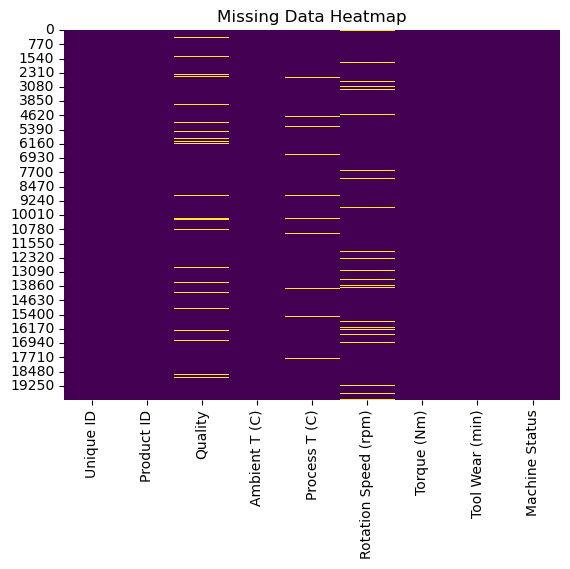

In [58]:
# Visualise missing values with a heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()


Correlation Matrix:
                       Unique ID  Ambient T (C)  Process T (C)  \
Unique ID              1.000000       0.080338       0.191775   
Ambient T (C)          0.080338       1.000000       0.876107   
Process T (C)          0.191775       0.876107       1.000000   
Rotation Speed (rpm)  -0.007274       0.024601       0.020030   
Torque (Nm)            0.001603      -0.013774      -0.012852   
Tool Wear (min)       -0.005351       0.013849       0.013870   
Machine Status        -0.011446       0.082530       0.035989   

                      Rotation Speed (rpm)  Torque (Nm)  Tool Wear (min)  \
Unique ID                        -0.007274     0.001603        -0.005351   
Ambient T (C)                     0.024601    -0.013774         0.013849   
Process T (C)                     0.020030    -0.012852         0.013870   
Rotation Speed (rpm)              1.000000    -0.874754         0.003145   
Torque (Nm)                      -0.874754     1.000000        -0.003093   
To

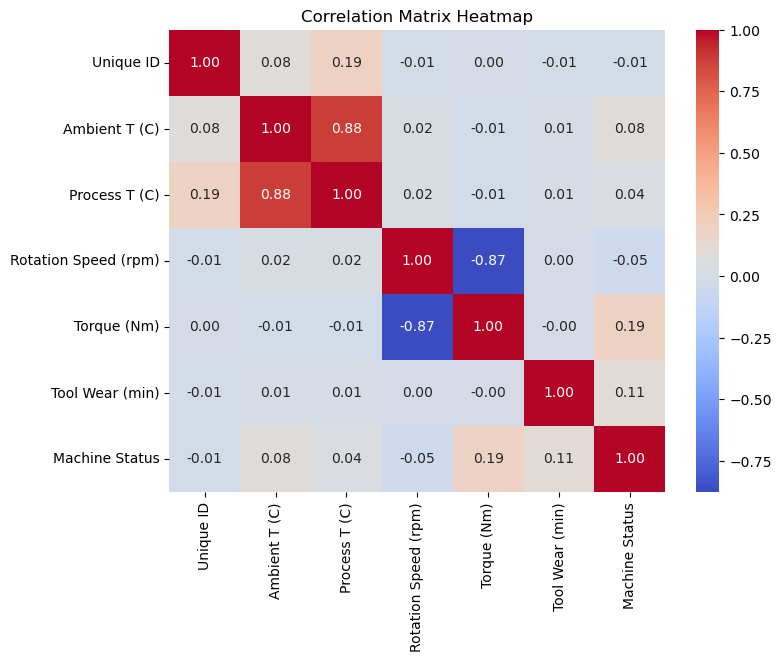

In [59]:
# Compute correlation matrix (only numeric columns)
corr_matrix = df.corr(numeric_only=True)

# Display the correlation matrix
print("Correlation Matrix:\n", corr_matrix)

# Visualize with a heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

#### **Missing Data and Correlation Analysis**

A heatmap of missing values was generated to visualize data completeness across all features. The visualization revealed that most columns were fully populated, with only a few containing missing entries — primarily in **Quality**, **Process T (C)**, and **Rotation Speed (rpm)**. These gaps appear scattered rather than concentrated, indicating that the missingness is likely random and not tied to a specific subset of the data. This suggests that any imputation or removal during preprocessing will not bias the dataset.

Next, a **correlation matrix heatmap** was constructed to examine relationships between numerical variables. The strongest positive correlation (**r ≈ 0.88**) was observed between **Ambient Temperature** and **Process Temperature**, suggesting that changes in the surrounding environment directly influence process conditions. Conversely, a strong negative correlation (**r ≈ -0.87**) was found between **Rotation Speed (rpm)** and **Torque (Nm)**, indicating that as rotational speed increases, torque tends to decrease — a relationship consistent with mechanical behavior. Other variables, such as **Tool Wear** and **Machine Status**, displayed weak correlations with the remaining features, implying limited direct dependency.

Overall, these analyses provided a clear overview of data quality and inter-variable relationships, serving as a foundation for further preprocessing and modeling.

